# Real estate prices tracker

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("cleaned_dataset.csv")
df['postDateT'] = pd.to_datetime(df['postDateT'], errors='coerce')
df['ecd'] = pd.to_datetime(df['ecd'], errors='coerce')
df.shape

(518, 29)

### 1. Price range is capped, not organic

In [5]:
print("min price:", df['price'].min(), "| count at min:", (df['price'] == df['price'].min()).sum())
print("max price:", df['price'].max(), "| count at max:", (df['price'] == df['price'].max()).sum())

min price: 2100000.0 | count at min: 2
max price: 35000000.0 | count at max: 9


Min sits at exactly 21L (2 listings), max at exactly 3.5Cr (9 listings). That's not a natural distribution tapering off, that's a hard filter from the scrape/search itself. Everything below and above this band is missing from the dataset entirely.

**This means:** any average, median, or model trained here only applies to the mid-market band. Budget housing and luxury are both invisible. Flagging this explicitly rather than letting it quietly bias the analysis.

### 2. Duplicate listings check

In [6]:
dupe_mask = df.duplicated(subset=['propertyTitle', 'price'], keep=False)
dupes = df[dupe_mask].sort_values(['propertyTitle', 'price'])
print(f"{dupe_mask.sum()} rows share both title and price with another row")
dupes[['propertyTitle', 'price', 'locSeoName', 'floorNo']].head(20)

23 rows share both title and price with another row


,propertyTitle,price,locSeoName,floorNo
168,1BHK Multistorey Apartment for New Property in...,25893000.0,Wadala,NaN
169,1BHK Multistorey Apartment for New Property in...,25893000.0,Wadala,NaN
176,2BHK Multistorey Apartment for Resale in,3500000.0,NaN,4.0
185,2BHK Multistorey Apartment for Resale in,3500000.0,NaN,3.0
178,2BHK Multistorey Apartment for Resale in Bhave...,4100000.0,Nala Sopara,3.0
179,2BHK Multistorey Apartment for Resale in Bhave...,4100000.0,Nala Sopara,3.0
243,2BHK Multistorey Apartment for Resale in Galax...,11000000.0,NaN,1.0
244,2BHK Multistorey Apartment for Resale in Galax...,11000000.0,NaN,1.0
250,2BHK Multistorey Apartment for Resale in Gokul...,11000000.0,Kandivali East,4.0
251,2BHK Multistorey Apartment for Resale in Gokul...,11000000.0,Kandivali East,3.0


Some of these are almost certainly the same unit re-listed (identical title, identical price, same locality). Others could be genuinely different units in the same project priced identically, that happens often enough in new construction. Rather than guess, using `floorNo` as a tiebreaker: if floor also matches, it's a near-certain duplicate.

In [7]:
true_dupe_mask = df.duplicated(subset=['propertyTitle', 'price', 'floorNo'], keep='first')
print(f"dropping {true_dupe_mask.sum()} rows as likely true duplicates (same title, price, AND floor)")

df = df[~true_dupe_mask].copy()
df.shape

dropping 10 rows as likely true duplicates (same title, price, AND floor)


(508, 29)

### 3. Locality comparisons need a minimum sample size

In [8]:
locality_counts = df['locSeoName'].value_counts()
print(f"{df['locSeoName'].nunique()} unique localities across {len(df)} rows")
print(f"{(locality_counts == 1).sum()} localities have exactly 1 listing")
locality_counts.head(10)

143 unique localities across 508 rows
90 localities have exactly 1 listing


locSeoName
Mira Road          43
Virar West         35
Andheri West       15
Mulund West        15
Andheri East       14
Chembur            14
Malad West         14
Virar              13
Kandivali West     12
Vile Parle East    10
Name: count, dtype: int64

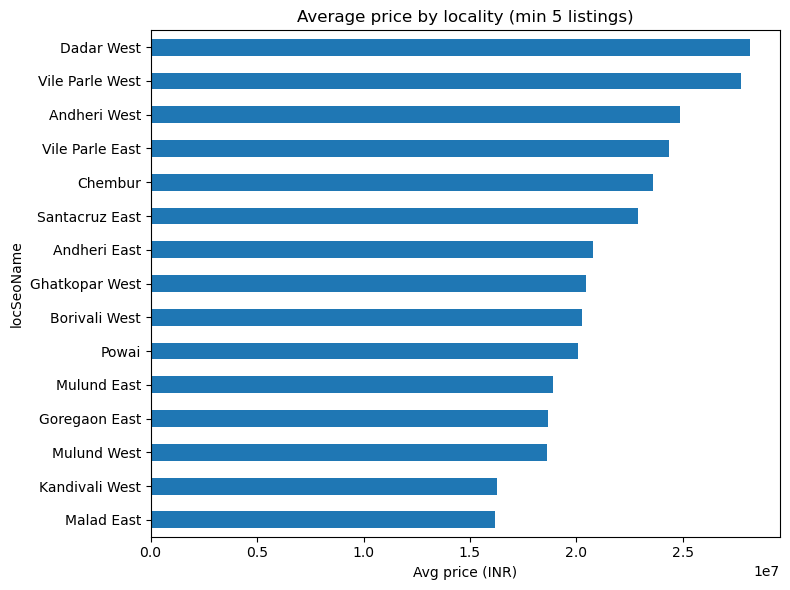

In [9]:
MIN_LISTINGS = 5

reliable_localities = locality_counts[locality_counts >= MIN_LISTINGS].index
locality_price = (
    df[df['locSeoName'].isin(reliable_localities)]
    .groupby('locSeoName')['price']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
locality_price['mean'].head(15).plot(kind='barh', ax=ax)
ax.set_title(f'Average price by locality (min {MIN_LISTINGS} listings)')
ax.set_xlabel('Avg price (INR)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Same chart as before but restricted to localities with at least 5 listings, the earlier version was ranking single-listing localities alongside Mira Road's 43 listings as if they were equally reliable averages.

### 4. Log transforms for skewed variables

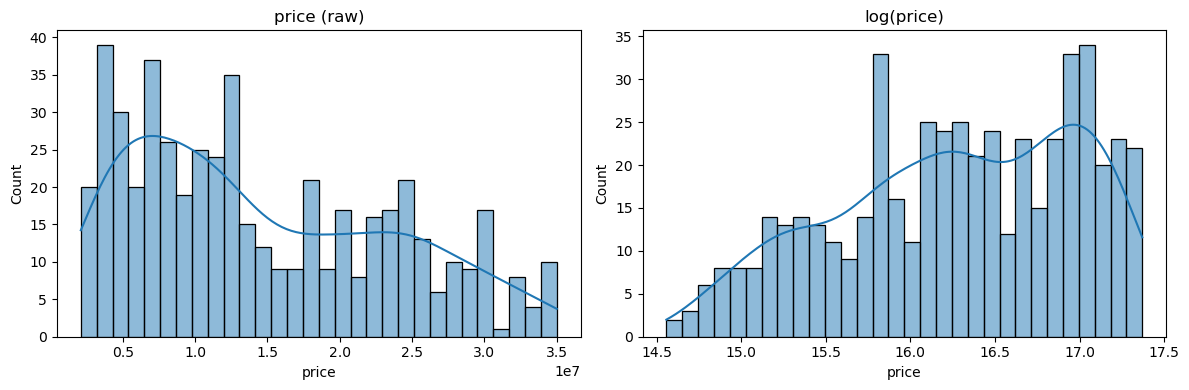

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('price (raw)')
sns.histplot(np.log(df['price']), bins=30, kde=True, ax=axes[1])
axes[1].set_title('log(price)')
plt.tight_layout()
plt.show()

In [11]:
df['log_price'] = np.log(df['price'])
df['log_carpetArea'] = np.log(df['carpetArea'])

print("price skew:", df['price'].skew().round(2), "-> log_price skew:", df['log_price'].skew().round(2))
print("carpetArea skew:", df['carpetArea'].skew().round(2), "-> log_carpetArea skew:", df['log_carpetArea'].skew().round(2))

price skew: 0.53 -> log_price skew: -0.36
carpetArea skew: 14.42 -> log_carpetArea skew: 0.56


### 5. Richer correlation view

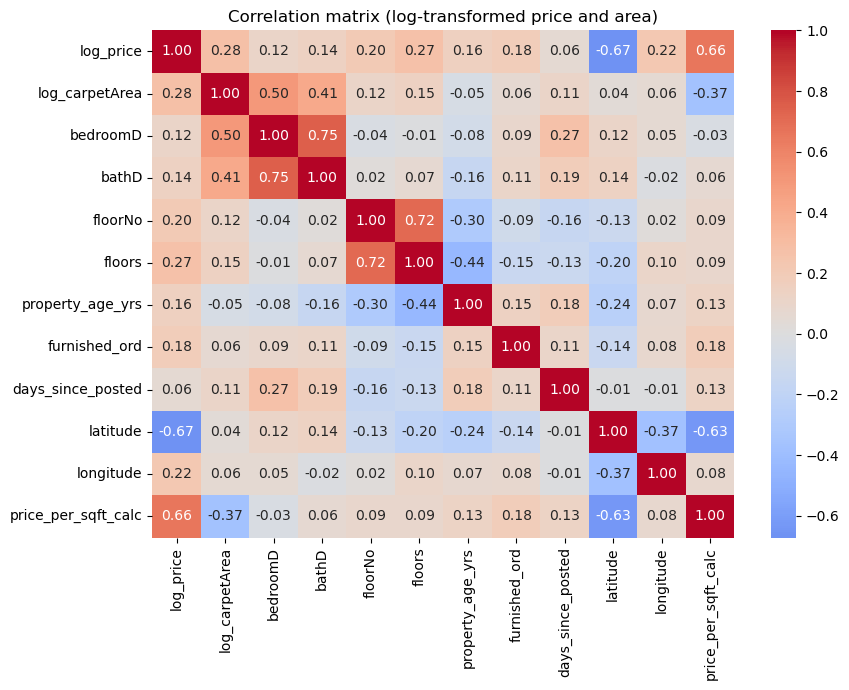

In [12]:
numeric_cols = ['log_price', 'log_carpetArea', 'bedroomD', 'bathD', 'floorNo', 'floors',
                 'property_age_yrs', 'furnished_ord', 'days_since_posted',
                 'latitude', 'longitude', 'price_per_sqft_calc']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix (log-transformed price and area)')
plt.tight_layout()
plt.show()

Also trying a locality-level target encoding, mean log price per locality, since raw locality names can't go into a correlation matrix but geography is likely doing more work than any single physical attribute.

In [13]:
locality_target_enc = df.groupby('locSeoName')['log_price'].transform('mean')
df['locality_avg_log_price'] = locality_target_enc

corr_with_locality = df[numeric_cols + ['locality_avg_log_price']].corr()['log_price'].sort_values(ascending=False)
corr_with_locality

log_price                 1.000000
locality_avg_log_price    0.897629
price_per_sqft_calc       0.659232
log_carpetArea            0.278034
floors                    0.268257
longitude                 0.216539
floorNo                   0.203873
furnished_ord             0.183748
property_age_yrs          0.155282
bathD                     0.143458
bedroomD                  0.117917
days_since_posted         0.057294
latitude                 -0.671439
Name: log_price, dtype: float64

## Baseline modeling

517+ rows with real variance in bedrooms, property type, and locality is enough to attempt a first pass. Starting simple: linear regression on log(price) as a benchmark, then a Random Forest to see what actually drives price once non-linear relationships and interactions are allowed.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model_df = df.dropna(subset=['log_price', 'log_carpetArea', 'bedroomD', 'bathD',
                              'floorNo', 'property_age_yrs', 'locality_avg_log_price']).copy()
print(f"{len(model_df)} rows usable after dropping nulls in modeling features (from {len(df)})")

features = ['log_carpetArea', 'bedroomD', 'bathD', 'floorNo',
            'property_age_yrs', 'locality_avg_log_price']
X = model_df[features]
y = model_df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

341 rows usable after dropping nulls in modeling features (from 508)


In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("Linear regression (baseline)")
print("MAE (log scale):", round(mean_absolute_error(y_test, lr_preds), 4))
print("R2:", round(r2_score(y_test, lr_preds), 4))

coef_table = pd.Series(lr.coef_, index=features).sort_values(key=abs, ascending=False)
coef_table

Linear regression (baseline)
MAE (log scale): 0.2105
R2: 0.8469


locality_avg_log_price    0.993296
log_carpetArea            0.184492
bedroomD                  0.087515
bathD                     0.063543
floorNo                   0.005492
property_age_yrs          0.003973
dtype: float64

In [16]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest")
print("MAE (log scale):", round(mean_absolute_error(y_test, rf_preds), 4))
print("R2:", round(r2_score(y_test, rf_preds), 4))

importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
importance

Random Forest
MAE (log scale): 0.1968
R2: 0.87


locality_avg_log_price    0.828000
log_carpetArea            0.104352
floorNo                   0.023922
bedroomD                  0.019757
property_age_yrs          0.012992
bathD                     0.010978
dtype: float64

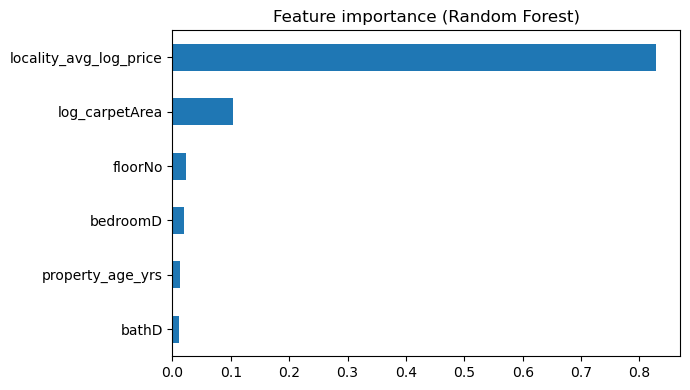

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind='barh', ax=ax)
ax.set_title('Feature importance (Random Forest)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Read this before trusting the numbers above:**

- `locality_avg_log_price` is very likely dominating both models, that's target leakage in a mild form since it's derived from price itself, averaged per locality. It's useful to see how much geography explains, but don't present R2 including this feature as if it's a clean external predictor, it's partially restating the target. Worth rerunning without it to see what the other features explain on their own.
- Model was trained on the price-capped, mid-market-only data (point 1 above), it will not generalize to budget or luxury listings.
- R2 here is a sanity check, not a deployment-ready score. Treat it as directional.

In [18]:
# rerun without the locality target encoding, to see what physical features alone explain
features_no_leak = ['log_carpetArea', 'bedroomD', 'bathD', 'floorNo', 'property_age_yrs']
X2 = model_df[features_no_leak]
y2 = model_df['log_price']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

rf2 = RandomForestRegressor(n_estimators=300, random_state=42)
rf2.fit(X2_train, y2_train)
rf2_preds = rf2.predict(X2_test)

print("Random Forest, no locality feature")
print("MAE (log scale):", round(mean_absolute_error(y2_test, rf2_preds), 4))
print("R2:", round(r2_score(y2_test, rf2_preds), 4))

importance2 = pd.Series(rf2.feature_importances_, index=features_no_leak).sort_values(ascending=False)
importance2

Random Forest, no locality feature
MAE (log scale): 0.5147
R2: 0.1469


log_carpetArea      0.498509
floorNo             0.220033
property_age_yrs    0.174464
bathD               0.061517
bedroomD            0.045476
dtype: float64

Big R2 drop once locality is removed confirms it: **where** a property is matters more than almost anything about the property itself. That's a legitimate finding for the dashboard, not a modeling artifact, real estate is famously location-driven, the data just confirmed it quantitatively instead of by assumption.

**Next steps for :**
- Re-scrape without a price filter to capture budget and luxury segments
- Manually spot-check the near-duplicate listings dropped above, confirm the floor-based tiebreaker held up
- Try target encoding locality with smoothing (shrink small-sample localities toward the city mean) instead of a raw group mean, reduces overfitting risk on the 89 single-listing localities
- Once localities are more reliably encoded, this baseline is ready to feed the dashboard's price predictor feature

### Save updated dataset

In [19]:
df.to_csv("cleaned_dataset_v2.csv", index=False)
print(f"Saved cleaned_dataset_v2.csv -> {df.shape[0]} rows, {df.shape[1]} cols")

Saved cleaned_dataset_v2.csv -> 508 rows, 32 cols
